In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text

In [2]:
df=pd.read_csv("../data/processed/insurance_claims_interpretable.csv")
df.head()

,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,...,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,age_semantic,claim_semantic,months_as_customer_semantic
0,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,...,6510,13020,52080,Saab,92x,2004,Y,Adulto_Esperto,Danno_Estremo,Cliente_Storico
1,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,...,780,780,3510,Mercedes,E400,2007,Y,Giovane_Adulto,Danno_Moderato,Cliente_Storico
2,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,...,7700,3850,23100,Dodge,RAM,2007,N,Giovane_Adulto,Danno_Moderato,Cliente_Storico
3,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,...,6340,6340,50720,Chevrolet,Tahoe,2014,Y,Giovane_Adulto,Danno_Estremo,Cliente_Storico
4,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,...,1300,650,4550,Accura,RSX,2009,N,Giovane_Adulto,Danno_Moderato,Cliente_Storico


In [3]:
from sklearn.preprocessing import StandardScaler


X=df.drop(columns=["fraud_reported"])
Y=df["fraud_reported"].apply(lambda x: 1 if x=="Y" else 0)

numeric_features=X.select_dtypes(include=["int64","float64"]).columns
scaler=StandardScaler()
X[numeric_features]=scaler.fit_transform(X[numeric_features])

X_encoded=pd.get_dummies(X)
X_train,X_test,y_train,y_test=train_test_split(X_encoded,Y,test_size=0.2,random_state=42)

In [4]:
from sklearn.ensemble import RandomForestClassifier


rf_clf=RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(X_train,y_train)
print("Modello Random Forest addestrato con successo!")

Modello Random Forest addestrato con successo!


Prendiamo le 3 variabili che avevano maggiore incidenza nelle classificazioni di prima

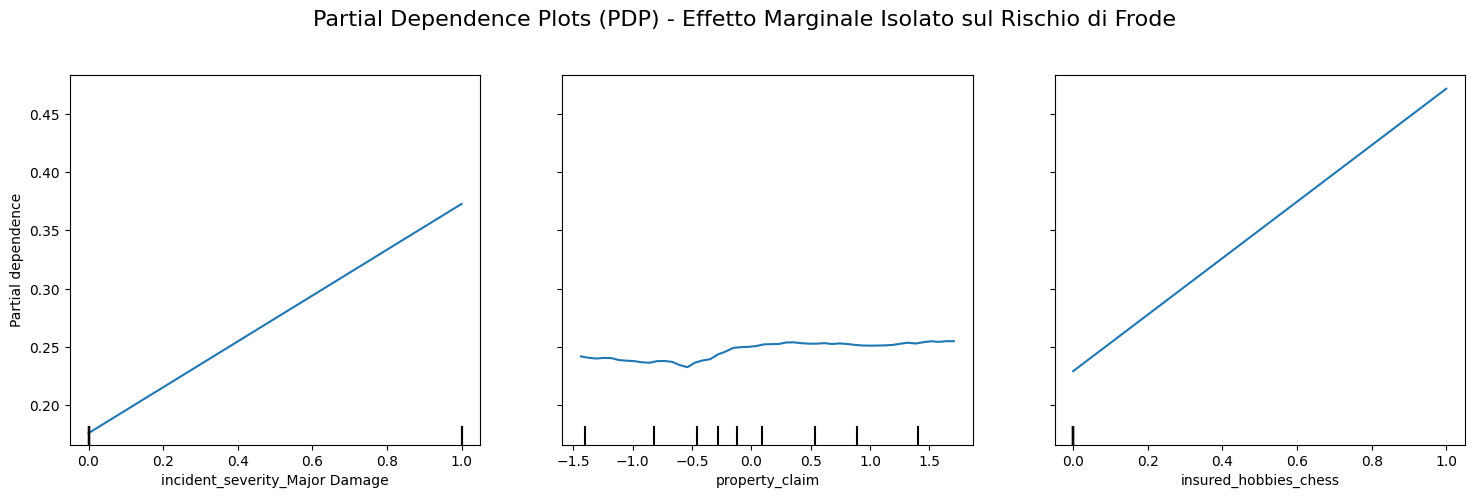

In [5]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features_to_plot = [
    'incident_severity_Major Damage', 
    'property_claim', 
    'insured_hobbies_chess' 
]

fig,ax=plt.subplots(figsize=(18,5))
display=PartialDependenceDisplay.from_estimator(
    estimator=rf_clf,
    X=X_train,
    features=features_to_plot,
    ax=ax,
    kind="average",
    grid_resolution=50
)
fig.suptitle("Partial Dependence Plots (PDP) - Effetto Marginale Isolato sul Rischio di Frode", fontsize=16)
plt.subplots_adjust(top=0.85)
plt.show()

In [6]:
from sklearn.inspection import permutation_importance
print("Calcolo della Permutation Feature Importance in corso...")

result=permutation_importance(rf_clf,X_test,y_test,n_repeats=10,random_state=42,n_jobs=-1)

pfi_importances=pd.Series(result.importances_mean,index=X_test.columns)

Calcolo della Permutation Feature Importance in corso...


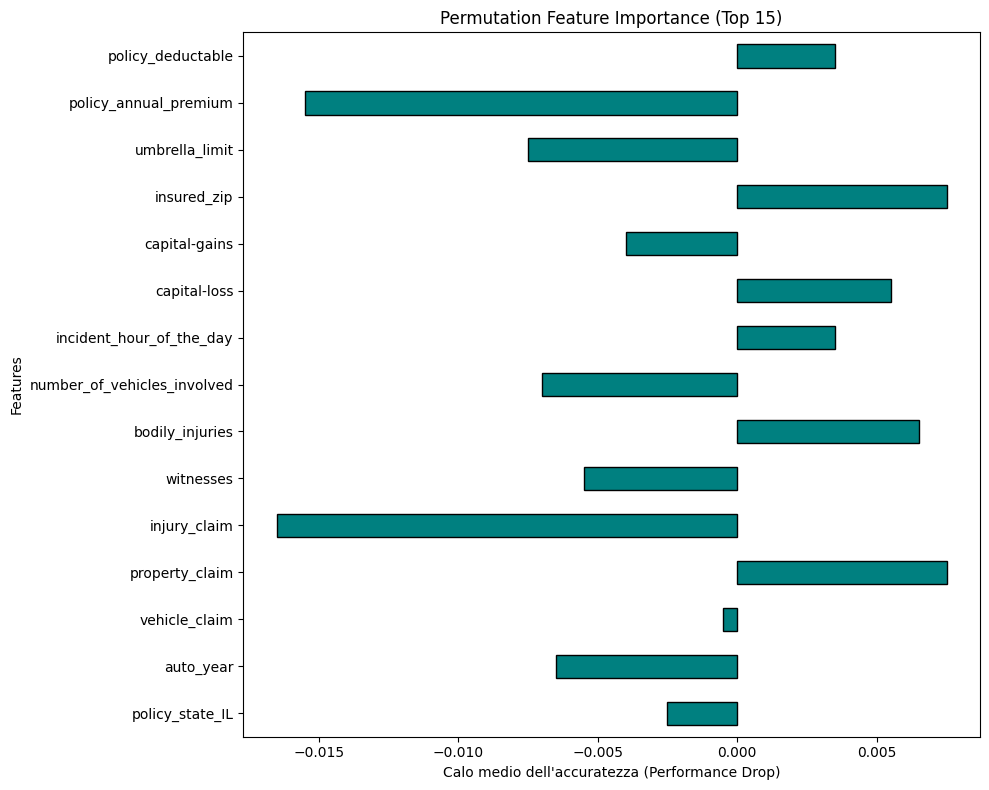

TOP FEATURE PIÙ IMPORTANTI (PFI)
policy_deductable: 0.0035
policy_annual_premium: -0.0155
umbrella_limit: -0.0075
insured_zip: 0.0075
capital-gains: -0.0040
capital-loss: 0.0055
incident_hour_of_the_day: 0.0035
number_of_vehicles_involved: -0.0070
bodily_injuries: 0.0065
witnesses: -0.0055


In [7]:
pfi_importances_sorted = pfi_importances.sort_values(ascending=False)
top_features=pfi_importances.head(15)
fig, ax = plt.subplots(figsize=(10, 8))
top_features.plot.barh(ax,ax,color='teal',edgecolor='black')
ax.set_title("Permutation Feature Importance (Top 15)")
ax.set_xlabel("Calo medio dell'accuratezza (Performance Drop)")
ax.set_ylabel("Features")
ax.invert_yaxis()  # Capovolge l'asse Y per avere la più importante in alto
plt.tight_layout()
plt.show()

print("TOP FEATURE PIÙ IMPORTANTI (PFI)")
for feature,importance in top_features.head(10).items():
    print(f"{feature}: {importance:.4f}")

In [11]:
#%pip install shap
import shap

explainer=shap.TreeExplainer(rf_clf)
shap_values=explainer(X_test)


In [21]:
indice_pratica=0
X_test.iloc[[indice_pratica]]

,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,...,age_semantic_Giovane_Adulto,age_semantic_Neopatentato,claim_semantic_Danno_Estremo,claim_semantic_Danno_Grave,claim_semantic_Danno_Lieve,claim_semantic_Danno_Moderato,months_as_customer_semantic_Cliente_Consolidato,months_as_customer_semantic_Cliente_Recente,months_as_customer_semantic_Cliente_Storico,months_as_customer_semantic_Nuovo_Cliente
521,1.412784,-0.489197,-0.479476,-0.451296,0.228798,0.953851,1.490523,-0.823865,0.009759,1.362107,...,True,False,True,False,False,False,False,False,False,True


In [22]:
predizione=rf_clf.predict(X_test.iloc[[indice_pratica]])[0]


np.int64(0)


--- Analisi SHAP Locale per la Pratica Assicurativa #0 ---
Esito reale (y_test): Legittimo
Predizione Random Forest: Legittimo


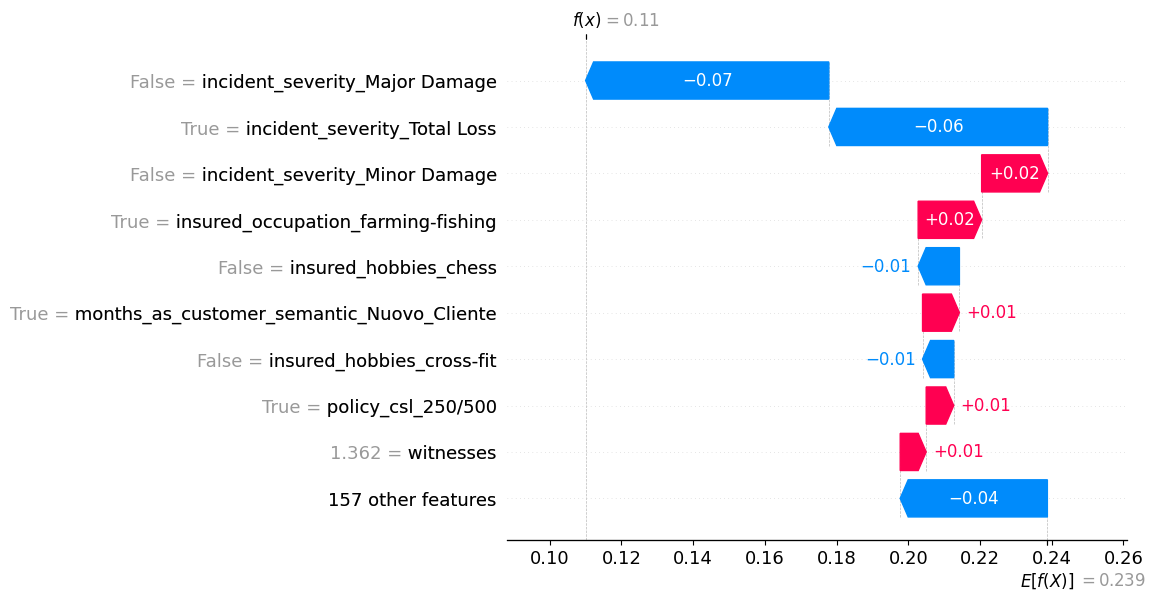

In [26]:
print(f"\n--- Analisi SHAP Locale per la Pratica Assicurativa #{indice_pratica} ---")
print(f"Esito reale (y_test): {'Frode' if y_test.iloc[indice_pratica] == 1 else 'Legittimo'}")
print(f"Predizione Random Forest: {'Frode' if predizione == 1 else 'Legittimo'}")

shap.plots.waterfall(shap_values[indice_pratica, :, 1])

--- SHAP Beeswarm Plot: Impatto Globale e Direzione delle Feature ---


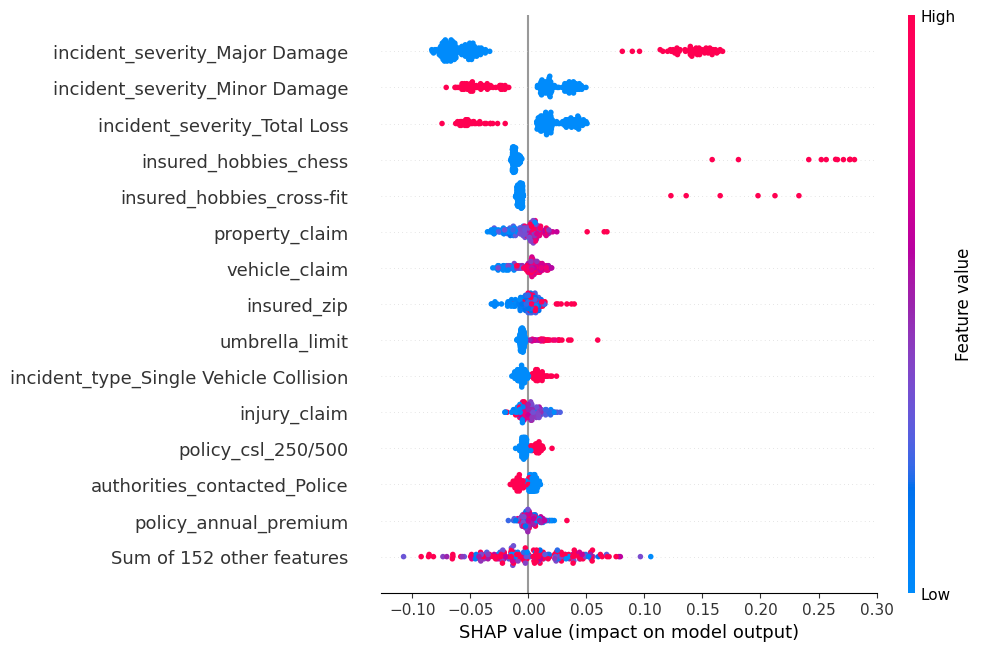

In [29]:
print("--- SHAP Beeswarm Plot: Impatto Globale e Direzione delle Feature ---")
plt.figure(figsize=(12,8))
shap.plots.beeswarm(shap_values[:,:,1],max_display=15)
plt.show()


--- SHAP Scatter Plot: Analisi dell'impatto di 'insured_hobbies_chess' ---


<Figure size 800x500 with 0 Axes>

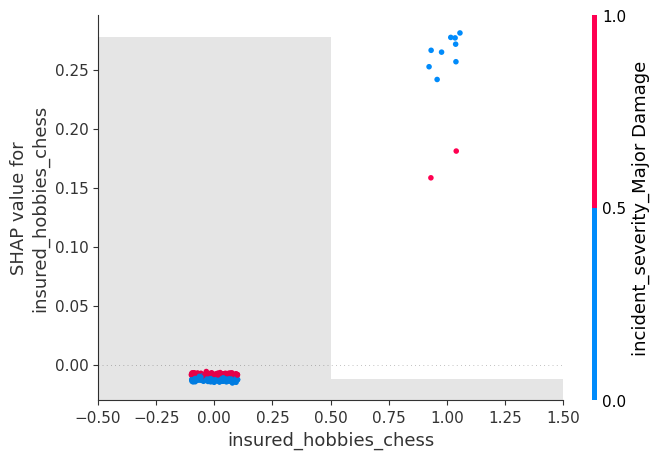

In [28]:
feature_da_esplorare = "insured_hobbies_chess"
print(f"\n--- SHAP Scatter Plot: Analisi dell'impatto di '{feature_da_esplorare}' ---")
plt.figure(figsize=(8,5))
shap.plots.scatter(shap_values[:,feature_da_esplorare,1],color=shap_values[:,:,1])
plt.show()

Inizializzazione dell'Explainer LIME...
Generazione del Modello Surrogato Locale per la pratica #0...


/home/emmanuelmessina00/.venvs/ai-core/lib64/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


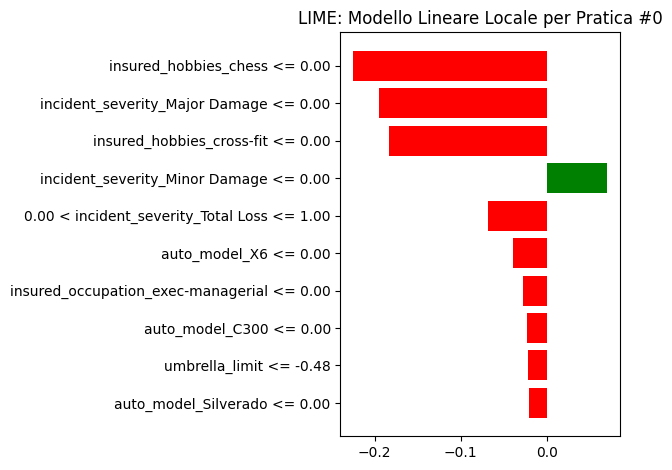


Pesi della Regressione Locale LIME:
insured_hobbies_chess <= 0.00: -0.2250
incident_severity_Major Damage <= 0.00: -0.1951
insured_hobbies_cross-fit <= 0.00: -0.1829
incident_severity_Minor Damage <= 0.00: 0.0702
0.00 < incident_severity_Total Loss <= 1.00: -0.0688
auto_model_X6 <= 0.00: -0.0398
insured_occupation_exec-managerial <= 0.00: -0.0279
auto_model_C300 <= 0.00: -0.0226
umbrella_limit <= -0.48: -0.0219
auto_model_Silverado <= 0.00: -0.0203


In [37]:
#%pip install lime
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt


print("Inizializzazione dell'Explainer LIME...")
explainer_lime=lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.to_list(),
    class_names=['Legittimo','Frode'],
    mode='classification',
    random_state=42
)
print(f"Generazione del Modello Surrogato Locale per la pratica #{indice_pratica}...")
exp=explainer_lime.explain_instance(
    data_row=X_test.iloc[indice_pratica].values,
    predict_fn=rf_clf.predict_proba,
    num_features=10,
)
fig = exp.as_pyplot_figure()
plt.title(f"LIME: Modello Lineare Locale per Pratica #{indice_pratica}")
plt.tight_layout()
plt.show()

print("\nPesi della Regressione Locale LIME:")
for feature, weight in exp.as_list():
    print(f"{feature}: {weight:.4f}")